In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from itertools import combinations

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state = 0)
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
def bootstrap(X, y, N):
  n = X.shape[0]
  idx = np.random.choice(n, size=N, replace=True)
  X_new = X[idx].copy()
  y_new = y[idx].copy()

  for i in range(X.shape[1]):
    noise_std = np.std(X[:, i])
    noise = np.random.normal(0, 0.25 * noise_std, N)
    X_new[:, i] += noise

  return X_new, y_new

In [ ]:
filter = y != 0
data2 = X[filter]
target2 = y[filter]
target_names2 = target_names[1:]
target2 = target2 - 1
data2, target2 = bootstrap(data2, target2, 1000)
X_train2, X_test2, y_train2, y_test2 = train_test_split(data2, target2, random_state = 0)

In [ ]:
# print(X_train2.max(axis=0))
# print((X_train2.max(axis=0) - X_train2.min(axis=0)) * 1e-4)

In [ ]:
X_train3 = X_train2[y_train2 == 1]
print(X_train3.shape)

(370, 4)


In [ ]:
class DefinitelyNotADecisionTree:
  def __init__(self, data, div_per_dim=2, levels=3):
    self.data = np.asarray(data)
    self.div_per_dim = div_per_dim
    self.levels = levels
    self.N = self.data.shape[1]
    self.lower_bounds = self.data.min(axis=0)
    self.upper_bounds = self.data.max(axis=0)
    padding = (self.upper_bounds - self.lower_bounds) * 1e-4
    self.lower_bounds -= padding
    self.upper_bounds += padding

    self.floor_region_size = (self.upper_bounds - self.lower_bounds) / div_per_dim

    self.good_regions = self._flag_regions()

  def _get_region_bounds(self, region_idx, level):
    region_size = self.floor_region_size / (self.div_per_dim ** (level - 1))
    region_idx_array = np.array(region_idx)
    region_lower_bounds = self.lower_bounds + region_idx_array * region_size
    region_upper_bounds = region_lower_bounds + region_size

    return region_lower_bounds, region_upper_bounds

  def _get_region_idx(self, point, level):
    region_size = self.floor_region_size / (self.div_per_dim ** (level - 1))
    idx = ((point - self.lower_bounds) / region_size).astype(int)
    max_idx = self.div_per_dim ** level - 1
    good_idx = np.clip(idx, 0, max_idx)

    return tuple(good_idx.tolist())

  def _flag_regions(self):
    non_empties = {}
    non_empties[1] = set()

    for point_idx, point in enumerate(self.data):
      region_idx = self._get_region_idx(point, level=1)
      non_empties[1].add(region_idx)

    for level in range(2, self.levels + 1):
      non_empties[level] = set()

      for bigger_region_idx in non_empties[level - 1]:
        bigger_lower_bounds, bigger_upper_bounds = self._get_region_bounds(bigger_region_idx, level - 1)
        mask = np.all((self.data >= bigger_lower_bounds) & (self.data <= bigger_upper_bounds), axis=1)
        points_in_bigger = self.data[mask]

        for point in points_in_bigger:
          region_idx = self._get_region_idx(point, level)
          #print(type(region_idx), region_idx, type(level), level)
          non_empties[level].add(region_idx)

    return non_empties

  def get_empty_regions(self, level):
    regions_per_dim = self.div_per_dim ** level
    not_empty = self.good_regions[level]
    all_regions = itertools.product(range(regions_per_dim), repeat=self.N)

    empty_regions = [region_idx for region_idx in all_regions
                     if region_idx not in not_empty]

    return empty_regions

  def predict(self, test_data):
    test_data = np.asarray(test_data)

    if test_data.ndim == 1:
      test_data = test_data.reshape(1, -1)

    labels = np.zeros(len(test_data), dtype=int)

    lowest_level = self.levels
    lowest_non_empty = self.good_regions[lowest_level]

    for i, point in enumerate(test_data):
      if np.all(point >= self.lower_bounds) and np.all(point <= self.upper_bounds):
        region_idx = self._get_region_idx(point, lowest_level)

        if region_idx in lowest_non_empty:
          labels[i] = 1

    return labels

  def get_info(self):
    info = {}
    for level in range(1, self.levels + 1):
      n_non_empty = len(self.good_regions[level])
      total_regions = self.div_per_dim ** (level * self.N)
      info[level] = {
          'non-empty': n_non_empty,
          'total': total_regions,
          'non-empty percentage': n_non_empty / total_regions * 100
      }

    return info


  # def _flag_regions(self):
  #   non_empty = set()

  #   for point in self.data:
  #     region_idx = self._get_region_idx(point)
  #     non_empty.add(region_idx)

  #   return non_empty

  # def predict(self, test_data):
  #   test_data = np.asarray(test_data)

  #   if test_data.ndim == 1:
  #     test_data = test_data.reshape(1, -1)

  #   labels = np.zeros(len(test_data), dtype=int)

  #   for i, point in enumerate(test_data):
  #     if np.all(point >= self.lower_bounds) and np.all(point<= self.upper_bounds):
  #       region_idx = self._get_region_idx(point)
  #       if region_idx in self.good_regions:
  #         labels[i] = 1

  #   return labels

In [ ]:
model = DefinitelyNotADecisionTree(X_train3, div_per_dim=2, levels=4)
#print(f'N of good regions: {len(model.good_regions)}')
#print(f'Good regions idxs: {model.good_regions}')

In [ ]:
labels = model.predict(X_train2)
print(labels.shape)
# print(labels)
# print(y_train2 ^ 1)
info = model.get_info()
for level, item in info.items():
  print(f'Level {level}: {item['non-empty']}/{item['total']} ({item['non-empty percentage']}%)')

(750,)
Level 1: 15/16 (93.75%)
Level 2: 71/256 (27.734375%)
Level 3: 225/4096 (5.4931640625%)
Level 4: 357/65536 (0.54473876953125%)


In [ ]:
# print(labels)
# print(y_train2)

In [ ]:
class_1_mask = ((y_train2) == 1)
class_1_accuracy = np.mean(labels[class_1_mask] == 1)
print(class_1_accuracy)

1.0


In [ ]:
print(model.good_regions[4])
print(model.get_empty_regions(4))

{(15, 14, 11, 7), (12, 11, 7, 13), (9, 10, 10, 12), (11, 7, 8, 8), (6, 6, 5, 1), (12, 7, 9, 1), (11, 8, 7, 8), (8, 9, 7, 5), (9, 10, 5, 9), (6, 10, 8, 13), (9, 7, 10, 10), (9, 9, 10, 12), (9, 10, 6, 10), (7, 6, 6, 9), (12, 6, 12, 8), (15, 14, 11, 11), (0, 3, 3, 4), (6, 6, 4, 4), (7, 4, 4, 4), (11, 12, 9, 12), (8, 6, 7, 9), (7, 4, 7, 0), (11, 9, 8, 5), (7, 8, 7, 10), (7, 5, 3, 7), (12, 7, 9, 5), (8, 5, 4, 8), (9, 2, 8, 5), (7, 6, 6, 4), (5, 4, 5, 6), (9, 7, 5, 11), (9, 3, 8, 4), (8, 4, 2, 7), (6, 10, 7, 11), (8, 9, 9, 14), (4, 7, 3, 8), (13, 13, 10, 13), (8, 7, 5, 6), (8, 5, 8, 9), (9, 4, 6, 11), (4, 5, 2, 6), (7, 5, 2, 5), (3, 6, 2, 5), (7, 7, 8, 6), (6, 4, 7, 2), (6, 6, 7, 4), (8, 10, 8, 12), (12, 5, 12, 7), (4, 5, 6, 8), (5, 0, 4, 1), (4, 1, 4, 2), (12, 6, 11, 7), (10, 7, 6, 9), (6, 5, 2, 4), (13, 6, 12, 7), (15, 15, 13, 10), (14, 8, 10, 11), (7, 10, 6, 11), (5, 6, 6, 3), (10, 8, 6, 8), (15, 3, 13, 9), (13, 3, 12, 10), (10, 8, 10, 5), (9, 5, 7, 9), (10, 3, 9, 5), (13, 7, 10, 8), (8, 

In [ ]:
proj = list(combinations(range(4), 2))

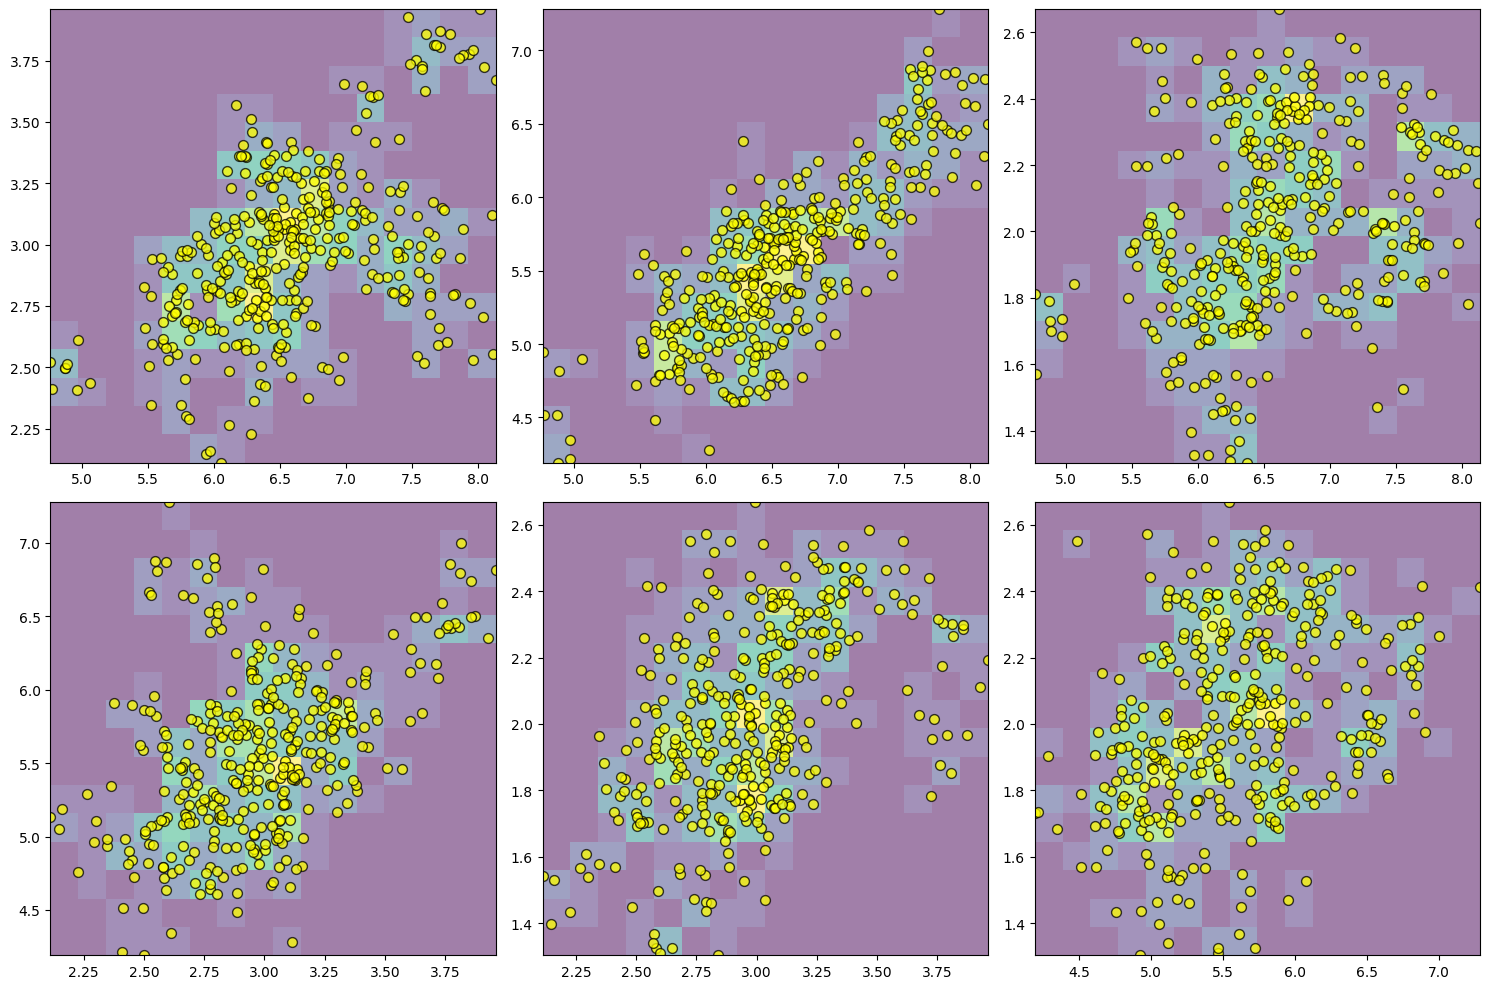

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
regions_per_dim = model.div_per_dim ** 4
not_empty = model.good_regions[4]

colors = ['yellow']#, 'blue']
cmap = 'viridis'

for i, (feat1, feat2) in enumerate(proj):
  ax = axes[i]

  grid = np.zeros((regions_per_dim, regions_per_dim))

  for region_idx in not_empty:
    i = region_idx[feat1]
    j = region_idx[feat2]
    grid[j, i] += 1

  x_min, x_max = model.lower_bounds[feat1], model.upper_bounds[feat1]
  y_min, y_max = model.lower_bounds[feat2], model.upper_bounds[feat2]
  x_edges = np.linspace(x_min, x_max, regions_per_dim + 1)
  y_edges = np.linspace(y_min, y_max, regions_per_dim + 1)

  # x = np.arange(regions_per_dim + 1)
  # y = np.arange(regions_per_dim + 1)
  # X, Y = np.meshgrid(x, y)

  # levels = np.linspace(0, grid.max(), 3)
  # contour = ax.contourf(X, Y, grid, levels=levels, cmap=plt.cm.RdYlBu)
  # clrmesh = ax.pcolormesh(x, y, grid, cmap='inferno', shading='flat')

  clrmesh = ax.pcolormesh(x_edges, y_edges, grid, cmap=cmap, shading='flat', alpha=0.5)

  X_slice = X_train2[:, [feat1, feat2]]
  for i, color in enumerate(colors):
    idx_class = np.where(y_train2 == i + 1)
    ax.scatter(X_slice[idx_class, 0], X_slice[idx_class, 1], c=color, edgecolor='#000000', s=50, alpha=0.75)

plt.tight_layout()
plt.show()